In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

In [3]:
!uv pip install -qU yfinance

In [4]:
from typing import Literal
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool
# from langgraph.prebuilt import create_react_agent         is deprecated ... ?????????

from langchain.agents import create_agent
from langgraph.graph.message import MessagesState
from langgraph.types import Command
from langchain_core.messages import HumanMessage

market_research_agent = create_agent(
                llm, 
                tools=[YahooFinanceNewsTool()],
                system_prompt='You are a market researcher. Provide fact only not opinions'
)

def market_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = market_research_agent.invoke(state)
    
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='market_research')]},
        goto='supervisor'
        )

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
import yfinance as yf

from langchain.tools import tool

@tool
def get_stock_price(ticker: str) -> dict:
    """Given a stock ticker, return the price data for the past month"""
    stock_info = yf.download(ticker, period='1mo').to_dict()
    return stock_info

stock_research_tools = [get_stock_price]
stock_research_agent = create_agent(
    llm,
    tools = stock_research_tools,
    system_prompt='You are a stock market researcher. Provide fact only not opinions'
)

def stock_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = stock_research_agent.invoke(state)
    
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='stock_research')]},
        goto='supervisor'
    )

In [6]:
@tool
def company_research_tool(ticker: str) -> dict:
    """Given a ticker, return the financial information and SEC filings"""
    company_info = yf.Ticker(ticker)
    financial_info = company_info.get_financials()
    sec_filings = company_info.get_sec_filings()
    return {
        'financial_info': financial_info,
        'sec_filings': sec_filings
    }

company_research_tools = [company_research_tool]
company_research_agent = create_agent(
    llm,
    tools = company_research_tools,
    system_prompt='You are a company researcher. Provide fact only not opinions'
)

def company_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = company_research_agent.invoke(state)
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='company_research')]},
        goto='supervisor'
    )




In [13]:
from langchain_core.prompts import PromptTemplate

analyst_prompt = PromptTemplate.from_template(
    """You are a stock market analyst. Given the following information, 
Please decide wheter to buy, sell, or hold the stock.

Information:
{messages}"""
)

analyst_chain = analyst_prompt | llm

def analyst_node(state: MessagesState):
    result = analyst_chain.invoke({'messages': state['messages'][1:]})
    return {'messages': [result]}

In [7]:
!uv pip install langgraph-supervisor

Audited 1 package in 10ms


In [8]:
from typing import Literal
from typing_extensions import TypedDict

from langgraph.graph import MessagesState, END
from langgraph.types import Command


members = ["market_research", "stock_research", "company_research"]
options = members + ["FINISH"]

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)


class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal[*options]



def supervisor_node(state: MessagesState) -> Command[Literal[*members, "analyst"]]:
    messages = [
        {"role": "system", "content": system_prompt},
    ] + state["messages"]
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]
    if goto == "FINISH":
        goto = "analyst"

    return Command(goto=goto)

In [14]:
from langgraph.graph import StateGraph, START

graph_builder = StateGraph(MessagesState)

graph_builder.add_node("supervisor", supervisor_node)
graph_builder.add_node("market_research", market_research_node)
graph_builder.add_node("stock_research", stock_research_node)
graph_builder.add_node("company_research", company_research_node)
graph_builder.add_node("analyst", analyst_node)

In [15]:
graph_builder.add_edge(START, "supervisor")
graph_builder.add_edge("analyst", END)
graph = graph_builder.compile()

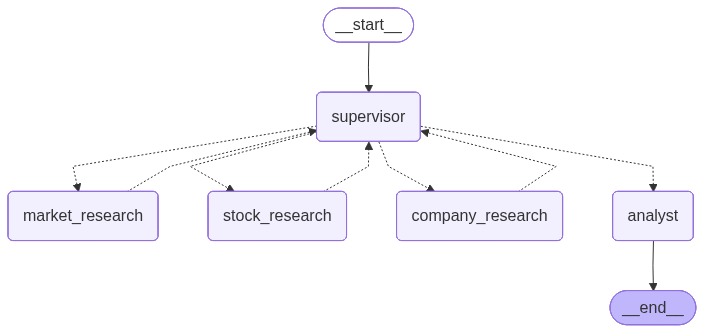

In [17]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
for chunk in graph.stream(
    {"messages": [("user", "Would you invest in Snowflake?")]}, stream_mode="values"
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

Would you invest in Snowflake?
================================ Human Message =================================
Name: market_research

Here are some recent developments regarding Snowflake Inc. (NYSE: SNOW):

1. **Analyst Ratings:**
   - DA Davidson has reiterated a Buy rating on Snowflake, setting a price target of $300.00.
   - Bank of America Securities has also reiterated a Buy rating, but with a lowered price target from $310 to $275. Snowflake is highlighted as one of the best software stocks to buy.

2. **Energy Solutions Initiative:**
   - Snowflake has launched new Energy Solutions focused on unifying data governance, AI analytics, and partner-built tools for the energy sector. This initiative includes collaborations with companies like Itron, Argus, and Tredence, among others. The solutions target uses such as grid modernization and decarbonization efforts.

3. **AI Stock Consideration:**
   - S

[*********************100%***********************]  1 of 1 completed


================================ Human Message =================================
Name: stock_research

Here is the stock price data for Snowflake (ticker: SNOW) over the past month:

- **December 31, 2025 to January 30, 2026:**
  - **Opening Prices:**
    - December 31: $221.63
    - January 2: $219.90
    - January 5: $217.35
    - January 6: $225.50
    - January 7: $234.00
    - January 8: $235.83
    - January 9: $224.40
    - January 12: $216.50
    - January 13: $220.00
    - January 14: $208.00
    - January 15: $205.47
    - January 16: $208.53
    - January 20: $206.51
    - January 21: $207.08
    - January 22: $208.93
    - January 23: $213.29
    - January 26: $211.79
    - January 27: $213.15
    - January 28: $214.21
    - January 29: $205.23
    - January 30: $200.65
  
  - **Closing Prices:**
    - December 31: $219.36
    - January 2: $216.71
    - January 5: $224.36
    - January 6: $234.53
    - January 7: $233.50
    - January 8: $223.79
    - January 9: $219.09
   

의문 
 여기서 node로 사용하지않고 tool로 변경하는 이유는?



 명시적인 기능차이는 없지만 코드 상으로는 좀 더 클린한 상태가 돼는것 같다.



다만 어떤 점이 장점인가?



https://docs.langchain.com/oss/python/langgraph/graph-api


공식 문서에 의하면 node는 로직을 인코딩하는 함수이다. "현재 상태"를 입력으로 받아 특정 계산이나 부작용을 수행하고, "업데이트된 상태를 반환한다."
Nodes와 Edges는 그저 함수일 뿐이며, LLM을 포함할 수도 있고 일반 코드를 포함할 수도 있습니다.
node
흐름 제어 중심: 워크플로우의 한 단계(State)를 담당하며, 다음 동작으로 넘어가기 위한 처리를 합니다.
tool
행동 중심: "검색", "DB 조회", "계산", "이메일 전송" 등 구체적인 행동을 정의합니다.


여기서 알수 있듯이 노드는 실제로 작업을 수행하고, 엣지는 다음에 무엇을 해야 할지 알려주는 역할이다.

multi tool은 하나의 에이전트에 여러가지 도구를 제공하는 개념이고, multi agent는 multi tool을 가진 에이전트가 여러개라고 보시면 됩니다. 라는 답변이 있다.

툴은 하나의 노드에 툴을 붙여 작용하게 하는것.....음..... 

# 그럼 여기서 MCP랑 Tool의 차이? 그리고 MCP, claude code skills는 ? MCP랑 subagent?

tool은 기능 그차체, MCP는 protocol, 도구를 연결하는 통로.

Tool (도구): AI가 실행할 수 있는 개별 함수

애플리케이션 코드 내에 직접 구현

특정 프레임워크(LangChain, LangGraph 등)에 종속

| 구분 | Tool | MCP |
|------|------|-----|
| **레벨** | 구현체 (Implementation) | 프로토콜 (Specification) |
| **범위** | 단일 애플리케이션 내 | 여러 클라이언트에서 재사용 |
| **배포** | 앱과 함께 배포 | 독립 서버로 운영 |
| **표준화** | 프레임워크마다 다름 | Anthropic 표준 규격 |
| **비유** | 직접 만든 함수 | REST API처럼 외부 서비스로 노출 |

MCP (Model Context Protocol): 서로 다른 앱이나 데이터베이스(Slack, GitHub, SQL 등)를 AI에 연결하는 표준 규격.
LLM과 외부 도구/데이터 소스 간의 통신 규격. 쉽게 말해 "Tool을 제공하는 표준화된 방법".
MCP Server금융 데이터 조회 기능을 별도 서버로 분리하여 다른 앱에서도 재사용

# 그럼 tool은 코드로 직접 구현하는것이고 MCP는 특정 서비스가 제공하는 tool을 사용할수 있게 해주는 표준 규격의 차이인가? tool로써 MCP를 호출하는것인가?
┌─────────────────────────────────────────────────────────────┐
│                      LLM Agent                              │
│                                                             │
│   LLM이 호출할 수 있는 "Tool" 목록:                           │
│   ┌─────────────────────────────────────────────────────┐   │
│   │                                                     │   │
│   │  1. 직접 구현한 Tool (Local)                         │   │
│   │     - calculate_budget()                            │   │
│   │     - parse_receipt()                               │   │
│   │                                                     │   │
│   │  2. MCP를 통해 연결된 Tool (Remote)                   │   │
│   │     - [MCP] slack_send_message()                    │   │
│   │     - [MCP] github_create_issue()                   │   │
│   │     - [MCP] database_query()                        │   │
│   │                                                     │   │
│   └─────────────────────────────────────────────────────┘   │
│                                                             │
│   → LLM 입장에서는 둘 다 그냥 "Tool"                          │
│   → 호출 방식만 다름 (직접 실행 vs MCP 프로토콜 통신)           │
│                                                             │
└─────────────────────────────────────────────────────────────┘

Tool = 함수 호출
MCP = REST API 호출

 MCP는 Tool을 **표준화된 방식으로 외부에 노출**하는 프로토콜입니다. Tool이 "기능"이라면, MCP는 그 기능을 "서비스화"하는 방법입니다.
질문답변Tool은 코드로 직접 구현? ✅ 맞습니다

MCP는 Tool을 제공하는 표준 규격?✅ 맞습니다 

Tool로써 MCP를 호출?✅ 맞습니다. MCP 서버가 노출한 기능이 Tool로 변환되어 LLM이 호출합니다

MCP는 "원격 Tool을 표준화된 방식으로 가져다 쓸 수 있게 해주는 프로토콜"이고, LLM 입장에서는 로컬 Tool이든 MCP Tool이든 그냥 "Tool"입니다.

┌─────────────────────────────────────────────────────────────┐
│                      Agent System                           │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  ┌─────────────┐    참조     ┌──────────────────┐          │
│  │   Skills    │◄───────────│  Claude Code     │          │
│  │ (지침/매뉴얼) │            │  (작업 수행자)    │          │
│  └─────────────┘             └──────────────────┘          │
│                                                             │
│  ┌─────────────────────────────────────────────────────┐   │
│  │                    Main Agent                        │   │
│  │                                                      │   │
│  │   ┌──────────┐    ┌──────────┐    ┌──────────┐     │   │
│  │   │  Node 1  │───►│  Node 2  │───►│  Node 3  │     │   │
│  │   └──────────┘    └──────────┘    └──────────┘     │   │
│  │        │               │                            │   │
│  │        ▼               ▼                            │   │
│  │   ┌─────────┐    ┌──────────┐                      │   │
│  │   │  Tools  │    │ SubAgent │ (자체 LLM + Tools)   │   │
│  │   │(내장함수)│    └──────────┘                      │   │
│  │   └─────────┘                                       │   │
│  │        │                                            │   │
│  └────────┼────────────────────────────────────────────┘   │
│           │                                                 │
│           ▼ (MCP 프로토콜)                                  │
│  ┌─────────────────┐                                       │
│  │   MCP Server    │ (외부 서비스)                          │
│  │  - 표준화된 API  │                                       │
│  │  - 재사용 가능   │                                       │
│  └─────────────────┘                                       │
│                                                             │
└─────────────────────────────────────────────────────────────┘

Claude Code Skills는 Claude Code(CLI 도구)가 특정 작업을 수행하는 방법을 정의한 지침이다. Tool이나 MCP와는 완전히 다른 개념이다.


MCP vs SubAgent
추상화 레벨의 차이.

SubAgent는 독립적인 의사결정 능력을 가진 하위 에이전트.메인 에이전트가 복잡한 작업을 위임할 수 있는 대상

| 구분 | MCP | SubAgent |
|------|-----|----------|
| **지능** | 없음 (단순 기능 제공) | 있음 (자체 LLM으로 판단) |
| **자율성** | 호출되면 정해진 동작 수행 | 스스로 계획하고 실행 |
| **구조** | 단일 함수/API | 완전한 에이전트 그래프 |
| **상태** | Stateless (대부분) | Stateful (자체 상태 관리) |
| **복잡도** | 낮음 | 높음 |
```
┌─────────────────────────────────────────────────────────┐
│                    Main Agent                           │
│  ┌─────────────────────────────────────────────────┐   │
│  │                   LLM Core                       │   │
│  └─────────────────────────────────────────────────┘   │
│           │                           │                 │
│           ▼                           ▼                 │
│  ┌─────────────────┐        ┌─────────────────────┐    │
│  │   MCP Server    │        │     SubAgent        │    │
│  │  (단순 기능)     │        │  ┌─────────────┐   │    │
│  │                 │        │  │   자체 LLM   │   │    │
│  │  - DB 조회      │        │  └─────────────┘   │    │
│  │  - API 호출     │        │        │          │    │
│  │  - 파일 처리    │        │  ┌─────┴─────┐    │    │
│  │                 │        │  │자체 Tool들 │    │    │
│  └─────────────────┘        │  └───────────┘    │    │
│                             └─────────────────────┘    │
└─────────────────────────────────────────────────────────┘


결론. 조금 더 사용해보고 전부 직접 만들어보고 사용해봐야 확실한 이해가능할듯.

"